In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\checkpoints_lab_9\ML Lab\lab13\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [13]:
train_dir = r'C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\train'
validation_dir = r'C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\validation'
test_dir = r'C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\test'

In [14]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

In [15]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 127, 127, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 30, 30, 128)      

In [16]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

In [17]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [18]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [20]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [21]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 10,
                         callbacks = callbacks)

Epoch 1/10



50/50 [==============================] - ETA: 0s - loss: 1.4309 - acc: 0.4175
Epoch 1: val_loss improved from inf to 0.78604, saving model to C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\checkpoints_lab_9\ML Lab\lab13\E1-cp-0001-loss0.79.h5


c:\Users\M Ayub\anaconda3\envs\DSP\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


50/50 [==============================] - 137s 3s/step - loss: 1.4309 - acc: 0.4175 - val_loss: 0.7860 - val_acc: 0.5312
Epoch 2/10
50/50 [==============================] - ETA: 0s - loss: 0.7747 - acc: 0.6281
Epoch 2: val_loss improved from 0.78604 to 0.59563, saving model to C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\checkpoints_lab_9\ML Lab\lab13\E1-cp-0002-loss0.60.h5
50/50 [==============================] - 128s 3s/step - loss: 0.7747 - acc: 0.6281 - val_loss: 0.5956 - val_acc: 0.6607
Epoch 3/10
50/50 [==============================] - ETA: 0s - loss: 0.6130 - acc: 0.7281
Epoch 3: val_loss improved from 0.59563 to 0.46121, saving model to C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\checkpoints_lab_9\ML Lab\lab13\E1-cp-0003-loss0.46.h5
50/50 [==============================] - 112s 2s/step - loss: 0.6130 - acc: 0.7281 - val_loss: 0.4612 - val_acc: 0.7946
Epoch 4/10
50/50 [==============================] - ETA: 0s - loss: 0.4826 - acc: 0.8100
Epoch 4: val_loss improved from

In [22]:
model_history.history

{'loss': [1.4309452772140503,
  0.7747306227684021,
  0.6130236387252808,
  0.48258960247039795,
  0.5347453355789185,
  0.369465172290802,
  0.2980503737926483,
  0.29855966567993164,
  0.26808443665504456,
  0.23952127993106842],
 'acc': [0.41749998927116394,
  0.628125011920929,
  0.7281249761581421,
  0.8100000023841858,
  0.8199999928474426,
  0.8487499952316284,
  0.8612499833106995,
  0.8837500214576721,
  0.8918750286102295,
  0.9106249809265137],
 'val_loss': [0.7860350012779236,
  0.5956296920776367,
  0.4612136781215668,
  0.4213287830352783,
  0.30964598059654236,
  0.3686850666999817,
  0.3398750424385071,
  0.3392677903175354,
  0.3556285500526428,
  0.3105747699737549],
 'val_acc': [0.53125,
  0.6607142686843872,
  0.7946428656578064,
  0.7991071343421936,
  0.8392857313156128,
  0.8258928656578064,
  0.8258928656578064,
  0.8348214030265808,
  0.84375,
  0.8482142686843872]}

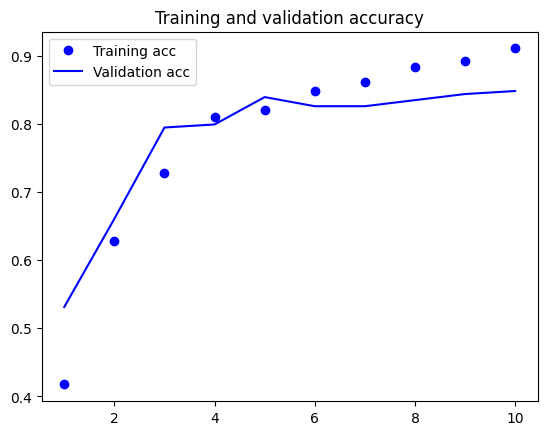

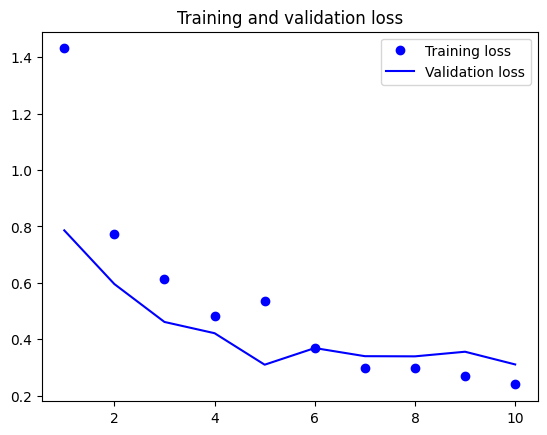

In [24]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_Accuracy.png')

Found 200 images belonging to 4 classes.
7/7 [==============================] - 4s 479ms/step


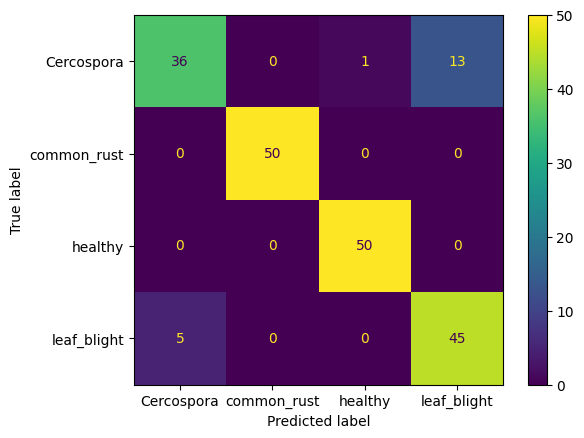

In [25]:
model = load_model(r'C:\Users\M Ayub\Downloads\ML_LAB\Computer vision\checkpoints_lab_9\ML Lab\lab13\E1-cp-0005-loss0.31.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [26]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.88      0.72      0.79        50
 common_rust       1.00      1.00      1.00        50
     healthy       0.98      1.00      0.99        50
 leaf_blight       0.78      0.90      0.83        50

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200

